In [207]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster,cophenet
from sklearn.preprocessing import StandardScaler
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [208]:
#usable functions

def show_elbow_silhouette(k_values, inertias, summary_scores_kmeans, title):
    #Gemini created the subplots

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('<b>Método del codo (Inercia)</b>', '<b>Silhouette Scores</b>')
    )

    fig.add_trace(go.Scatter(
        x=k_values,
        y=inertias,
        mode='lines+markers',
        name='Intercia (WCSS)',
        marker=dict(color='blue', size=10, line=dict(width=1, color='DarkSlateGrey')),
        line=dict(color='blue', width=2)
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=summary_scores_kmeans.index,
        y=summary_scores_kmeans['silhouette_score'],
        mode='lines+markers',
        name='Silhouette Score',
        marker=dict(color='green', size=10, line=dict(width=1, color='DarkSlateGrey')),
        line=dict(color='green', width=2)
    ), row=1, col=2)

    fig.update_layout(
        title=dict(
            text=f'<b>{title}</b>',
            x=0.5,
            font=dict(size=24, color='black')
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        showlegend=False, # The subplot titles are clear enough
        hovermode='x unified'
    )


    fig.update_xaxes(
        title_text='Número de clusters (k)',
        dtick=1, # Tick for every k-value
        gridcolor='rgba(200, 200, 200, 0.5)',
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        row=1, col=1 
    )
    fig.update_yaxes(
        title_text='Inercia (WCSS)',
        gridcolor='rgba(200, 200, 200, 0.5)',
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        row=1, col=1 
    )

    # 6. Update axes for Subplot 2 (Silhouette)
    fig.update_xaxes(
        title_text='Número de clusters (k)',
        dtick=1,
        gridcolor='rgba(200, 200, 200, 0.5)',
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        row=1, col=2
    )
    fig.update_yaxes(
        title_text='Silhouette Score',
        gridcolor='rgba(200, 200, 200, 0.5)',
        zeroline=False,
        showline=True,
        linewidth=1,
        linecolor='black',
        row=1, col=2
    )

    # Show the final combined figure
    fig.show()


def k_means_upto(rango, X_scaled):
    # Usando KMeans para determinar el numero de clusters
    k_values = [i for i in range(rango[0], rango[1])]
    inertias = []
    silhouette_scores_kmeans = []

    for k in k_values:
        k_means = KMeans(n_clusters=k, random_state=42, n_init='auto')
        cluster_labels = k_means.fit_predict(X_scaled)
        inertias.append(k_means.inertia_)
        #print(k_means.labels_)
        silhouette_scores_kmeans.append({'silhouette_score': silhouette_score(X_scaled, cluster_labels)})

    summary_scores_kmeans = pd.DataFrame(silhouette_scores_kmeans, index=k_values)

    return k_values, inertias, silhouette_scores_kmeans, summary_scores_kmeans

def plot_dendogram(X_scaled, name):
    # Dendrogram
    linkage_ward = linkage(X_scaled, method='ward')
    
    
    #Gemini was used to increase the quality of the plot
    plt.figure(figsize=(12, 8))

    ward_matrix = linkage_ward

    dendrogram(
        ward_matrix,
        truncate_mode='lastp',
        p=50,  # Show last 50 merges
        show_leaf_counts=True,
        leaf_rotation=90,
        leaf_font_size=10,
        show_contracted=True
    )

    plt.title(f"Ward's Linkage Dendrogram para {name}", fontsize=18, fontweight='bold')
    plt.xlabel('Cluster Size', fontsize=12)
    plt.ylabel('Distancia (Ward)', fontsize=12)


    plt.tight_layout()
    plt.show()


def plot_heatman_clusters(cluster_means_original, name):
    # Heatmap (improved by Gemini)
    scaler = StandardScaler()
    scaled_means_for_color = scaler.fit_transform(cluster_means_original)

    x_labels = [f'Cluster {i}' for i in cluster_means_original.index]
    y_labels = cluster_means_original.columns
    scaled_z_data = scaled_means_for_color.T  
    original_text_data = cluster_means_original.T  

    fig = go.Figure()

    fig.add_trace(go.Heatmap(
        z=scaled_z_data,                   
        x=x_labels,                        
        y=y_labels,                        
        
        text=original_text_data,           
        texttemplate="%{text:.2f}",        
        
        colorscale='RdBu_r',             
        colorbar_title='Valor escalado' 
    ))

    fig.update_layout(
        title_text=f'<b>Clusters con medias originales y colores escalados para {name}</b>',
        title_x = 0.5,
        xaxis_title='Cluster',
        yaxis_title='Variable',
        # Ensure all variable names are visible
        yaxis={'tickmode': 'array', 'tickvals': y_labels, 'ticktext': y_labels},
        height=600
    )
    fig.show()


# Productos

## Estandarización y selección de columnas para cluster de productos

In [209]:
#Leyendo el dataset
resumen_productos = pd.read_csv('../data_clean/resumen_productos.csv')
resumen_productos.head(5)

,ID_Producto,Nombre_producto,Categoría,Precio_Unitario,Stock,Unidades_Vendidas,Venta_Total,Transacciones,%_Unidades,%_Venta,Cancelada,Completa,Pendiente
0,6,Asado,Carnicería,28.56,5137,299,8539.44,81,2.863710,8.282421,0,71,10
1,8,Milanesa,Carnicería,16.21,3140,320,5187.20,89,3.064841,5.031076,0,76,13
2,25,Pizza congelada,Congelados,15.45,1640,332,5129.40,86,3.179772,4.975016,1,79,6
3,4,Queso rallado,Lácteos,19.23,2099,259,4980.57,77,2.480605,4.830665,1,67,9
4,3,Queso cremoso,Lácteos,17.23,3167,268,4617.64,84,2.566804,4.478659,0,66,18


In [210]:
resumen_productos['Porc_Canceladas'] = resumen_productos['Cancelada']/resumen_productos['Transacciones'] *100
resumen_productos['Porc_Completadas'] = resumen_productos['Completa']/resumen_productos['Transacciones'] *100
resumen_productos['Porc_Pendientes'] = resumen_productos['Pendiente']/resumen_productos['Transacciones'] *100


resumen_productos['Porc_Unidades'] = resumen_productos['%_Unidades']/100
resumen_productos['Porc_Ventas'] = resumen_productos['%_Venta']/100

In [211]:
resumen_productos = resumen_productos.drop(columns=['Cancelada', 'Completa', 'Pendiente', '%_Unidades', '%_Venta'])

resumen_productos.head(5)

,ID_Producto,Nombre_producto,Categoría,Precio_Unitario,Stock,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Porc_Unidades,Porc_Ventas
0,6,Asado,Carnicería,28.56,5137,299,8539.44,81,0.000000,87.654321,12.345679,0.028637,0.082824
1,8,Milanesa,Carnicería,16.21,3140,320,5187.20,89,0.000000,85.393258,14.606742,0.030648,0.050311
2,25,Pizza congelada,Congelados,15.45,1640,332,5129.40,86,1.162791,91.860465,6.976744,0.031798,0.049750
3,4,Queso rallado,Lácteos,19.23,2099,259,4980.57,77,1.298701,87.012987,11.688312,0.024806,0.048307
4,3,Queso cremoso,Lácteos,17.23,3167,268,4617.64,84,0.000000,78.571429,21.428571,0.025668,0.044787


In [212]:
#Filtrando las posibles columnas a usar
interest_cols = ['Unidades_Vendidas', 'Venta_Total', 'Transacciones', 'Porc_Unidades', 'Porc_Ventas', 'Precio_Unitario', 'Porc_Canceladas', 'Porc_Completadas', 'Porc_Pendientes', 'Stock']
X_prod = resumen_productos[interest_cols]
X_prod = X_prod.rename(columns={'Categoría': 'Categoria'})
X_prod.head(5)

,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Unidades,Porc_Ventas,Precio_Unitario,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Stock
0,299,8539.44,81,0.028637,0.082824,28.56,0.000000,87.654321,12.345679,5137
1,320,5187.20,89,0.030648,0.050311,16.21,0.000000,85.393258,14.606742,3140
2,332,5129.40,86,0.031798,0.049750,15.45,1.162791,91.860465,6.976744,1640
3,259,4980.57,77,0.024806,0.048307,19.23,1.298701,87.012987,11.688312,2099
4,268,4617.64,84,0.025668,0.044787,17.23,0.000000,78.571429,21.428571,3167


In [213]:
# Aplicando el StandardScaler a los datos 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_prod)
X_prod_scaled = pd.DataFrame(X_scaled_values, columns=X_prod.columns)

X_prod_scaled.head(5)

,Unidades_Vendidas,Venta_Total,Transacciones,Porc_Unidades,Porc_Ventas,Precio_Unitario,Porc_Canceladas,Porc_Completadas,Porc_Pendientes,Stock
0,0.589461,3.640095,0.217133,0.589461,3.640095,3.392403,-0.425004,0.766728,-0.708987,1.746380
1,1.100200,1.545681,1.063395,1.100200,1.545681,1.154800,-0.425004,0.279457,-0.209220,0.002711
2,1.392051,1.509568,0.746046,1.392051,1.509568,1.017101,0.986195,1.673173,-1.895691,-1.307005
3,-0.383374,1.416582,-0.205998,-0.383374,1.416582,1.701971,1.151140,0.628517,-0.854286,-0.906232
4,-0.164486,1.189831,0.534481,-0.164486,1.189831,1.339606,-0.425004,-1.190681,1.298620,0.026286


In [214]:
correlation =  X_prod.corr()

fig = px.imshow(correlation, text_auto=".2f")
fig.update_layout(width = 1200, height = 1200)
fig.show()

Como se puede observar, existen diversas variables altamente correlacionadas entre sí, lo cual no es ideal para la agrupación de datos ya que genera redundancia. Adicionalmente, tras realizar diversas pruebas de validación, se obtuvieron mejores resultados de clusterización al limitar el modelo a las siguientes columnas:

- Porc_Completadas
- Precio_Unitario
- Unidades_Vendidas

In [215]:
used_cols = ['Porc_Completadas', 'Precio_Unitario', 'Unidades_Vendidas']

X_prod_scaled = X_prod_scaled[used_cols]

X_prod_scaled.head(5)

,Porc_Completadas,Precio_Unitario,Unidades_Vendidas
0,0.766728,3.392403,0.589461
1,0.279457,1.154800,1.100200
2,1.673173,1.017101,1.392051
3,0.628517,1.701971,-0.383374
4,-1.190681,1.339606,-0.164486


## Elección de K

In [216]:
k_values, inertias, silhouette_scores_kmeans, summary_scores_kmeans = k_means_upto(X_scaled=X_prod_scaled, rango=(2, 11))

In [217]:
#K menas cluster analysis
show_elbow_silhouette(k_values=k_values, inertias=inertias, summary_scores_kmeans=summary_scores_kmeans, title='K-Means Cluster Análisis para Productos')

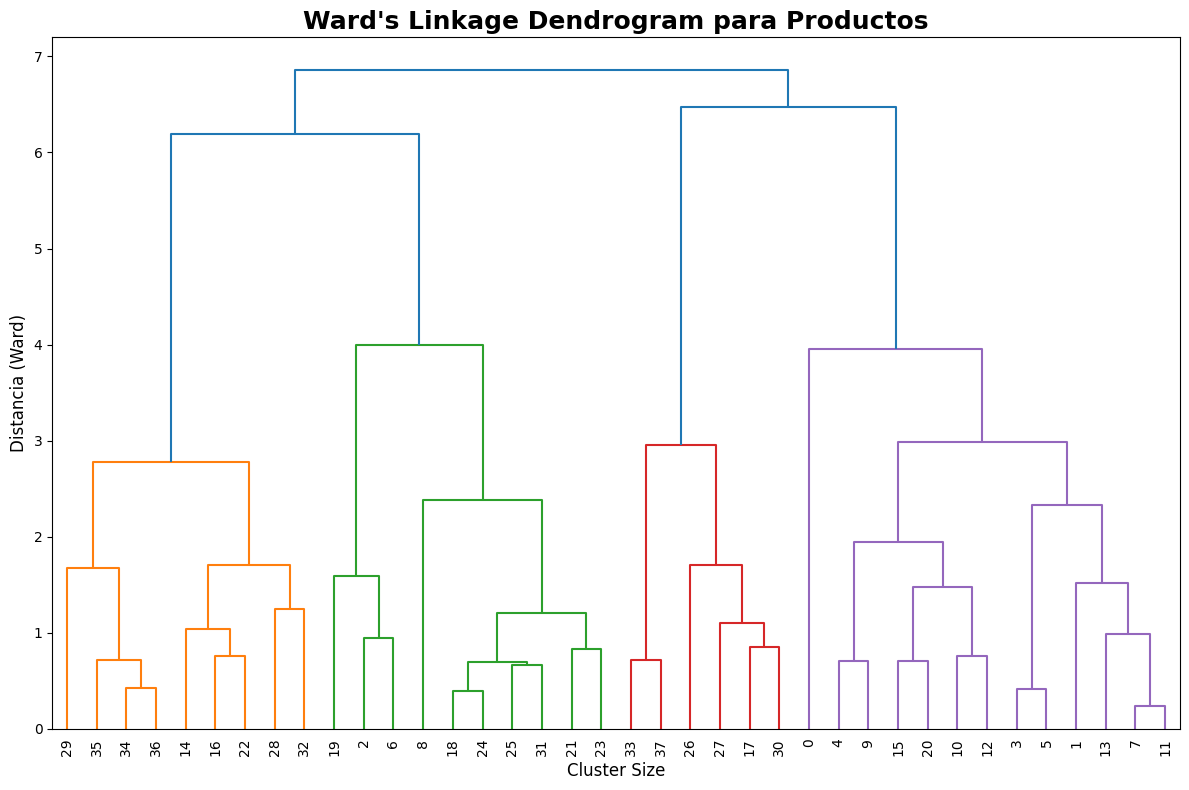

In [218]:
plot_dendogram(X_prod_scaled, name='Productos')

El valor final elegido es $k = 4$ , esto debido a que el análisis por el el método del codo deja de crecer en el intervalo (4-5), además de que el silluouete score no es malo en ese punto, pues se encuentra en un máximo local. 

Además de eso el análisis del Linkage Dendrogram muestra una recomendación de 4 clusters agrupados a una distancia suficiente para lograr una separación deseada, además de que se logra una mayor interpretabilidad de los clusters.

## Modelo final de Clustering

In [219]:
selected_k = 4

k_means_model = KMeans(n_clusters=selected_k, random_state=42, n_init='auto')
k_means_model.fit(X_prod_scaled)

df_labels = resumen_productos.copy()
df_labels['label'] = k_means_model.labels_

cluster_counts = df_labels['label'].value_counts().sort_index()
cluster_percentages = df_labels['label'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Percentage': cluster_percentages.values
})

print(cluster_summary.to_string())

   Cluster  Count  Percentage
0        0      9   23.684211
1        1     13   34.210526
2        2      5   13.157895
3        3     11   28.947368


In [220]:
cluster_means_original = df_labels.groupby('label')[used_cols].mean()

cluster_means_original

,Porc_Completadas,Precio_Unitario,Unidades_Vendidas
label,,,
0,86.608468,11.056667,240.333333
1,85.831884,6.166923,306.692308
2,87.567305,19.602000,291.200000
3,78.412720,8.735455,257.727273


In [221]:

plot_heatman_clusters(cluster_means_original, name='productos')

**Interpretación de los clusters de Productos**


- **Cluster 0 (Productos Estándar, 23.68%)**: Tienen un precio intermedio (11.06), pero son los que menos se venden (240.33). Sin embargo, su tasa de completitud es buena (86.61%). No son problemáticos, pero tampoco destacan.

- **Cluster 1 (Motores de Volumen, 34.21%)**: Son los productos "gancho". Tienen el precio más bajo (6.17) pero compensan con la mayor cantidad de unidades vendidas (306.69). Su tasa de completitud es saludable.

- **Cluster 2 (Productos Estrella, 13.15%)**: Tienen el precio más alto (19.60) y aun así mantienen un volumen de ventas muy alto (291.20), casi alcanzando al líder de volumen. Además, tienen la mejor tasa de completitud (87.57%), lo que indica satisfacción del cliente o eficiencia logística.

- **Cluster 3 (Productos Problemáticos, 28.94%)**: Son baratos (8.74), se venden poco comparado con los líderes, pero lo más crítico es el 78.41% de completitud. Algo está fallando en el proceso de venta o entrega.


In [222]:
data = []

for label in df_labels['label'].unique():
    df_subset = df_labels[df_labels['label'] == label]
    
    trace = go.Scatter3d(
        x=df_subset['Unidades_Vendidas'],
        y=df_subset['Precio_Unitario'],
        z=df_subset['Porc_Completadas'],
        mode='markers',
        name=str(label),  # Esto es lo que aparecerá en la leyenda
        marker=dict(
            size=5,       # Ajusta el tamaño si es necesario
            opacity=0.8
        )
    )
    data.append(trace)

layout = go.Layout(
    scene=dict(
        xaxis=dict(title='Unidades Vendidas'),
        yaxis=dict(title='Precio Unitario ($)'),
        zaxis=dict(title='Trans. Completas(%)')
    ),
    title="<b>Cluster de productos</b>",
    title_x = 0.5,
    width = 700,
    height = 700
)

# Creamos la figura con la lista de traces
fig = go.Figure(data=data, layout=layout)

fig.show()

# Clientes

## Estandarización y selección de columnas para cluster de clientes

In [223]:
clientes = pd.read_csv('../data_raw/clientes.csv')
clientes = clientes.rename(columns={'Fecha_Resgistro': 'Fecha_Registro', 'Región': 'Region'})
ventas = pd.read_csv('../data_raw/ventas.csv')

In [224]:
ventas_df = ventas.merge(resumen_productos[['ID_Producto', 'Precio_Unitario']], on='ID_Producto')

ventas_df['Total_gasto'] = ventas_df['Cantidad']*ventas_df['Precio_Unitario']

ventas_df = ventas_df.loc[ventas['Estado'] == 'Completa']

ventas_df

,ID_Venta,Fecha,ID_Cliente,ID_Producto,Cantidad,Método_Pago,Estado,Precio_Unitario,Total_gasto
0,919,31/01/2024,10,25,5,1,Completa,15.45,77.25
1,947,31/01/2024,106,5,1,4,Completa,5.65,5.65
2,1317,31/1/2024,235,25,3,3,Completa,15.45,46.35
3,1607,31/1/2024,114,15,5,1,Completa,3.51,17.55
4,2038,31/1/2024,132,2,5,4,Completa,5.21,26.05
...,...,...,...,...,...,...,...,...,...
3023,900,30/12/2024,248,10,5,1,Completa,14.25,71.25
3024,954,30/12/2024,44,12,6,4,Completa,8.12,48.72
3025,1390,30/12/2024,26,31,3,4,Completa,5.24,15.72
3026,1519,30/12/2024,246,11,3,3,Completa,11.23,33.69


In [225]:
products_by_client = ventas_df.groupby('ID_Cliente').agg(
    total_productos = ('Cantidad','sum'),
    total_gasto = ('Total_gasto', 'sum'),
    gasto_promedio = ('Total_gasto', 'mean')
).reset_index().join(
    pd.crosstab(index=ventas['ID_Cliente'], columns=ventas['Estado']), on='ID_Cliente'
).join(
    pd.crosstab(index=ventas['ID_Cliente'], columns=ventas['Método_Pago']), on='ID_Cliente'
)
products_by_client =  products_by_client.rename(columns={1:'forma_pago_1', 2:'forma_pago_2', 3:'forma_pago_3', 4:'forma_pago_4', 5:'forma_pago_5'})

products_by_client

,ID_Cliente,total_productos,total_gasto,gasto_promedio,Cancelada,Completa,Pendiente,forma_pago_1,forma_pago_2,forma_pago_3,forma_pago_4,forma_pago_5
0,1,41,287.77,26.160909,0,11,2,1,0,3,4,5
1,2,9,103.28,34.426667,0,3,1,1,0,0,2,1
2,3,23,160.24,22.891429,0,7,1,3,0,2,2,1
3,4,30,230.16,32.880000,0,7,1,2,1,2,2,1
4,5,19,164.48,23.497143,0,7,2,1,1,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
321,322,14,70.60,23.533333,0,3,1,0,0,2,2,0
322,323,28,231.98,25.775556,0,9,1,1,1,1,2,5
323,324,19,179.48,29.913333,0,6,1,2,1,1,2,1
324,325,40,314.16,26.180000,0,12,0,2,1,3,4,2


In [226]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID_Cliente      326 non-null    int64 
 1   Nombre          326 non-null    object
 2   Apellido        326 non-null    object
 3   Email           326 non-null    object
 4   Fecha_Registro  326 non-null    object
 5   Region          326 non-null    object
dtypes: int64(1), object(5)
memory usage: 15.4+ KB


In [227]:
products_by_client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       326 non-null    int64  
 1   total_productos  326 non-null    int64  
 2   total_gasto      326 non-null    float64
 3   gasto_promedio   326 non-null    float64
 4   Cancelada        326 non-null    int64  
 5   Completa         326 non-null    int64  
 6   Pendiente        326 non-null    int64  
 7   forma_pago_1     326 non-null    int64  
 8   forma_pago_2     326 non-null    int64  
 9   forma_pago_3     326 non-null    int64  
 10  forma_pago_4     326 non-null    int64  
 11  forma_pago_5     326 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 30.7 KB


In [228]:
clientes_info = clientes.merge(products_by_client, on='ID_Cliente')

clientes_info

,ID_Cliente,Nombre,Apellido,Email,Fecha_Registro,Region,total_productos,total_gasto,gasto_promedio,Cancelada,Completa,Pendiente,forma_pago_1,forma_pago_2,forma_pago_3,forma_pago_4,forma_pago_5
0,1,Karisa,Cromett,kcromett0@imageshack.us,19/11/2023,Patagonia,41,287.77,26.160909,0,11,2,1,0,3,4,5
1,2,Lenette,Seabert,lseabert1@yahoo.co.jp,07/05/2023,Patagonia,9,103.28,34.426667,0,3,1,1,0,0,2,1
2,3,Buddy,Silverson,bsilverson2@howstuffworks.com,27/03/2023,Patagonia,23,160.24,22.891429,0,7,1,3,0,2,2,1
3,4,Dan,Parkin,dparkin3@virginia.edu,26/10/2023,Buenos Aires,30,230.16,32.880000,0,7,1,2,1,2,2,1
4,5,Conney,Cassella,ccassella4@who.int,31/03/2023,Centro,19,164.48,23.497143,0,7,2,1,1,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,322,Hugh,Ortelt,hortelt8x@google.com.hk,19/11/2023,NEA,14,70.60,23.533333,0,3,1,0,0,2,2,0
322,323,Issiah,Schoales,ischoales8y@twitter.com,21/11/2023,Centro,28,231.98,25.775556,0,9,1,1,1,1,2,5
323,324,Nalani,Steggals,nsteggals8z@nhs.uk,01/09/2023,NEA,19,179.48,29.913333,0,6,1,2,1,1,2,1
324,325,Rowland,Riddington,rriddington90@friendfeed.com,16/06/2023,NEA,40,314.16,26.180000,0,12,0,2,1,3,4,2


In [229]:
products_by_client['Transacciones'] = products_by_client['Cancelada'] + products_by_client['Completa'] + products_by_client['Pendiente']

products_by_client['Porc_Canceladas'] = products_by_client['Cancelada']/(products_by_client['Transacciones']) *100
products_by_client['Porc_Completadas'] = products_by_client['Completa']/(products_by_client['Transacciones']) *100
products_by_client['Porc_Pendientes'] = products_by_client['Pendiente']/(products_by_client['Transacciones']) *100

products_by_client.drop(columns=['Cancelada', 'Completa', 'Pendiente'])

,ID_Cliente,total_productos,total_gasto,gasto_promedio,forma_pago_1,forma_pago_2,forma_pago_3,forma_pago_4,forma_pago_5,Transacciones,Porc_Canceladas,Porc_Completadas,Porc_Pendientes
0,1,41,287.77,26.160909,1,0,3,4,5,13,0.0,84.615385,15.384615
1,2,9,103.28,34.426667,1,0,0,2,1,4,0.0,75.000000,25.000000
2,3,23,160.24,22.891429,3,0,2,2,1,8,0.0,87.500000,12.500000
3,4,30,230.16,32.880000,2,1,2,2,1,8,0.0,87.500000,12.500000
4,5,19,164.48,23.497143,1,1,3,3,1,9,0.0,77.777778,22.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,322,14,70.60,23.533333,0,0,2,2,0,4,0.0,75.000000,25.000000
322,323,28,231.98,25.775556,1,1,1,2,5,10,0.0,90.000000,10.000000
323,324,19,179.48,29.913333,2,1,1,2,1,7,0.0,85.714286,14.285714
324,325,40,314.16,26.180000,2,1,3,4,2,12,0.0,100.000000,0.000000


In [230]:
clientes_info.to_csv('clientes_info.csv', index=False)

In [231]:
possible_cols_clients = ['total_productos', 'total_gasto', 'gasto_promedio','Porc_Canceladas', 'Porc_Completadas', 'Porc_Pendientes']

X_clients = products_by_client[possible_cols_clients]

X_clients

,total_productos,total_gasto,gasto_promedio,Porc_Canceladas,Porc_Completadas,Porc_Pendientes
0,41,287.77,26.160909,0.0,84.615385,15.384615
1,9,103.28,34.426667,0.0,75.000000,25.000000
2,23,160.24,22.891429,0.0,87.500000,12.500000
3,30,230.16,32.880000,0.0,87.500000,12.500000
4,19,164.48,23.497143,0.0,77.777778,22.222222
...,...,...,...,...,...,...
321,14,70.60,23.533333,0.0,75.000000,25.000000
322,28,231.98,25.775556,0.0,90.000000,10.000000
323,19,179.48,29.913333,0.0,85.714286,14.285714
324,40,314.16,26.180000,0.0,100.000000,0.000000


In [232]:
# Aplicando el StandardScaler a los datos 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_clients)
X_clients_scaled = pd.DataFrame(X_scaled_values, columns=X_clients.columns)

X_clients_scaled.head(5)

,total_productos,total_gasto,gasto_promedio,Porc_Canceladas,Porc_Completadas,Porc_Pendientes
0,1.315047,0.137685,-0.786256,-0.162326,0.015852,0.017675
1,-1.762936,-1.414944,-0.057692,-0.162326,-0.738005,0.771641
2,-0.416318,-0.935581,-1.074436,-0.162326,0.242009,-0.208515
3,0.256990,-0.347149,-0.194019,-0.162326,0.242009,-0.208515
4,-0.801066,-0.899898,-1.021047,-0.162326,-0.520224,0.553829


In [233]:
correlation =  X_clients_scaled.corr()

fig = px.imshow(correlation, text_auto=".2f")
fig.update_layout(width = 1200, height = 1200)
fig.show()

De este breve análisis se puede ver que al igual que el cluster anterior, se tienen altas correlaciones entre algunas variables, por lo que no se usarán todas para evitar redundancia de los datos. Finalmente luego de probar diversas combinaciones de columnas que no compartieran una correlación $> 0.8$ se eligieron las siguientes columnas para realizar el cluster: 

- total_gasto
- gasto_promedio
- Porc_Canceladas
- total_productos

In [234]:
selected_cols_clients = ['total_gasto', 'gasto_promedio', 'Porc_Canceladas', 'total_productos']

X_clients_scaled = X_clients_scaled[selected_cols_clients]

X_clients_scaled

,total_gasto,gasto_promedio,Porc_Canceladas,total_productos
0,0.137685,-0.786256,-0.162326,1.315047
1,-1.414944,-0.057692,-0.162326,-1.762936
2,-0.935581,-1.074436,-0.162326,-0.416318
3,-0.347149,-0.194019,-0.162326,0.256990
4,-0.899898,-1.021047,-0.162326,-0.801066
...,...,...,...,...
321,-1.689972,-1.017857,-0.162326,-1.282001
322,-0.331832,-0.820222,-0.162326,0.064616
323,-0.773661,-0.455508,-0.162326,-0.801066
324,0.359778,-0.784574,-0.162326,1.218860


## Selección de k para clientes

In [235]:
k_values, inertias, silhouette_scores_kmeans, summary_scores_kmeans = k_means_upto(X_scaled=X_clients_scaled, rango=(2, 11))

In [236]:
show_elbow_silhouette(k_values=k_values, inertias=inertias, summary_scores_kmeans=summary_scores_kmeans, title='K-Means Cluster Análisis para Clientes')

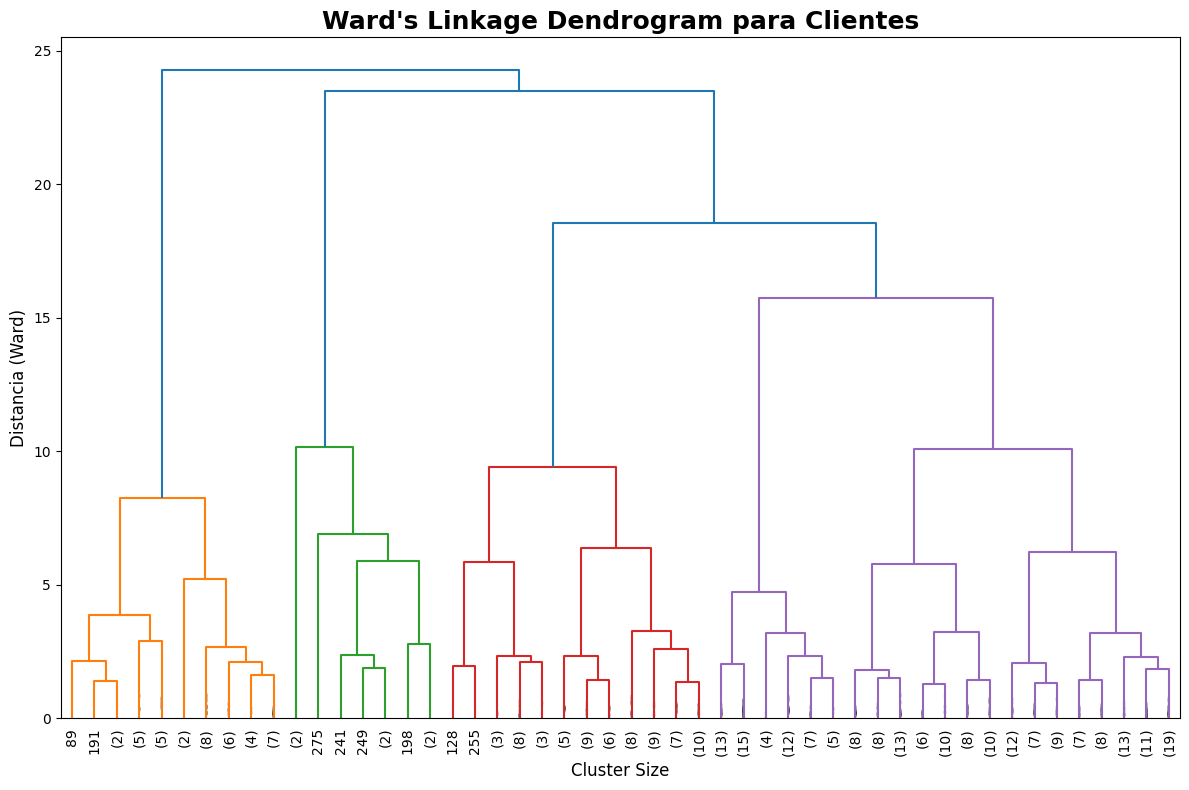

In [237]:
plot_dendogram(X_clients_scaled, name='Clientes')

Al analizar los gráficos es muy claro por los 3 métodos que recomiendan la clasificación de los clientes en 4 clusters, pues es en dónde se obtiene el máximo silhouette scores y en dónde se ve mas claramente el "codo". Debido a esto se utilizará $k = 4$.

Como nota, si se quitaba la variable total_productos, se lograba un mejor silhouette score, pero reducia los clusters a 3 y se tenía menor interpretabilidad.

## Modelo final de clustering para clientes

In [238]:
selected_k = 4

k_means_model = KMeans(n_clusters=selected_k, random_state=42, n_init='auto')
k_means_model.fit(X_clients_scaled)

df_labels = products_by_client.copy()
df_labels['label'] = k_means_model.labels_

cluster_counts = df_labels['label'].value_counts().sort_index()
cluster_percentages = df_labels['label'].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    'Cluster': cluster_counts.index,
    'Count': cluster_counts.values,
    'Percentage': cluster_percentages.values
})

print(cluster_summary.to_string())

   Cluster  Count  Percentage
0        0    147   45.092025
1        1    101   30.981595
2        2     70   21.472393
3        3      8    2.453988


In [239]:
cluster_means_original = df_labels.groupby('label')[selected_cols_clients].mean()

cluster_means_original

,total_gasto,gasto_promedio,Porc_Canceladas,total_productos
label,,,,
0,184.478707,26.998151,0.000000,21.619048
1,294.267723,44.089682,0.070721,25.891089
2,425.687143,38.249803,0.109890,42.142857
3,230.255000,42.149811,15.570437,20.750000


In [240]:
plot_heatman_clusters(cluster_means_original, name='Clientes')

**Interpretación de los clusters de Clientes**


- **Cluster 0 (Estables, 45.09%)**: Son clientes que compran productos baratos y gastan poco en total. Sin embargo, son extremadamente fiables; nunca cancelan.
- **Cluster 1 (Compradores Premium, 30.98%)**: No compran muchas cosas (volumen bajo), pero cuando compran, eligen lo más caro. Son clientes selectivos que buscan calidad o productos de gama alta.
- **Cluster 2 (Clientes VIP, 21.47%)**: Clientes que compran muchos productos y gastan mucho, son los más rentables por volumen. Llenan el carrito constantemente. Representan la mayor fuente de ingresos brutos.
- **Cluster 3 (Alto Riesgo, 2.45%)**: Son clientes problemáticos. Tienen una intención de compra alta (productos caros), pero una tasa de fricción operativa inaceptable. Posiblemente se arrepienten de la compra, tienen problemas con el pago, o son fraudes potenciales.